## This Project models the behavior of online shoppers. We will be performing Decision Tree, Random Forest, and ANN Predictive Models

# 1. Bring data into Google Colab

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
shoppers = pd.read_csv("/content/drive/MyDrive/Final Project/online_shoppers_intention.csv")

# 2. EDA

In [ ]:
# Check for missing values
print(shoppers.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [ ]:
shoppers.head()
shoppers.info()
shoppers.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


<Axes: xlabel='Month'>

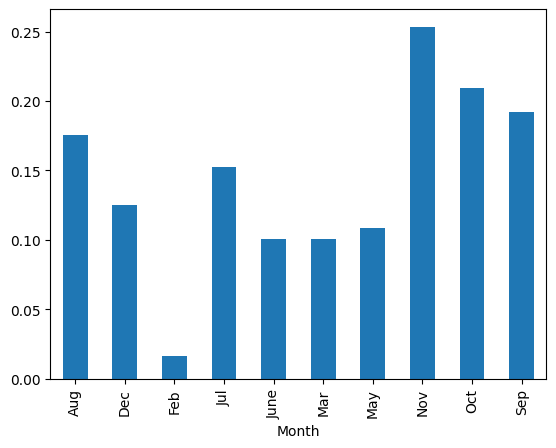

In [ ]:
shoppers.groupby('Month')['Revenue'].mean().plot(kind='bar')

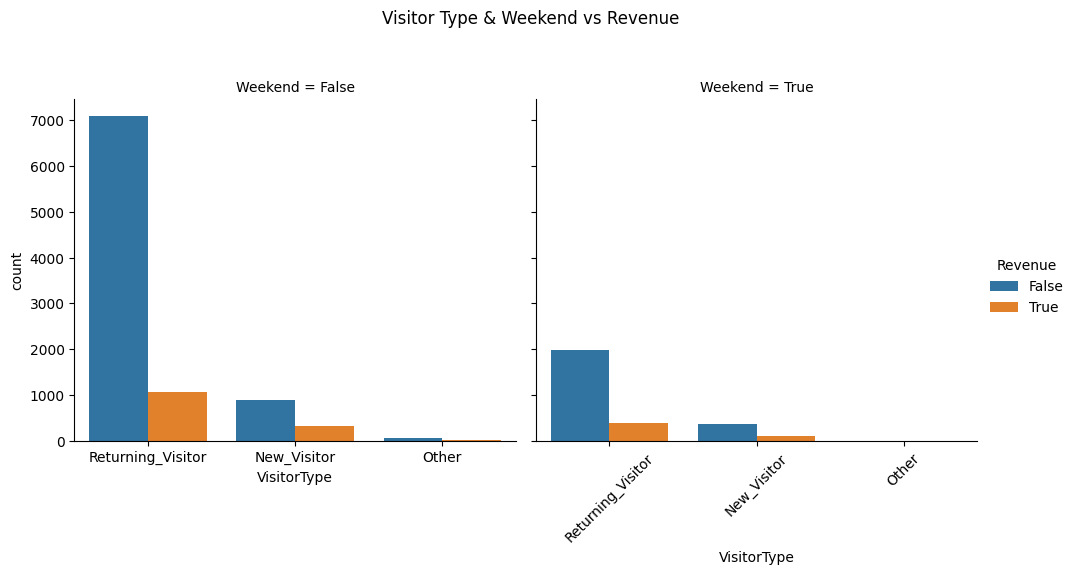

In [ ]:
sns.catplot(
    data=shoppers,
    x="VisitorType",
    hue="Revenue",
    col="Weekend",
    kind="count",
    height=5,
    aspect=1
)
plt.subplots_adjust(top=0.8)
plt.suptitle("Visitor Type & Weekend vs Revenue")
plt.xticks(rotation=45)
plt.show()


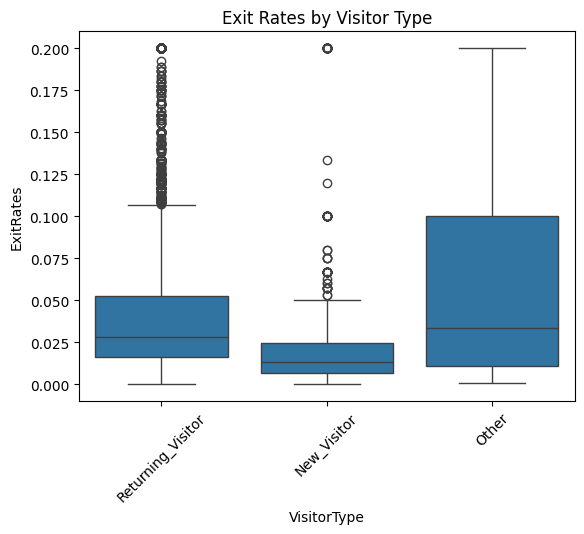

In [ ]:
sns.boxplot(data=shoppers, x='VisitorType', y='ExitRates')
plt.title('Exit Rates by Visitor Type')
plt.xticks(rotation=45)
plt.show()

# 3. Checking for Imbalance

In [ ]:
#Checking to see if dataset is imbalanced
shoppers['Revenue'].value_counts(normalize=True)

,proportion
Revenue,
False,0.845255
True,0.154745


Dataset is imbalanced. I will perform a stratified test-train split to account for this. I could also do balancing techniques.

# 4. Split the data

In [ ]:
y = shoppers['Revenue'] #excluding becuase its boolean already
#Encode
X = pd.get_dummies(shoppers.drop('Revenue', axis=1), drop_first=True)

# Stratified Train-test split because the dataset is imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=999
)

# 5. Modeling

## Decision Tree

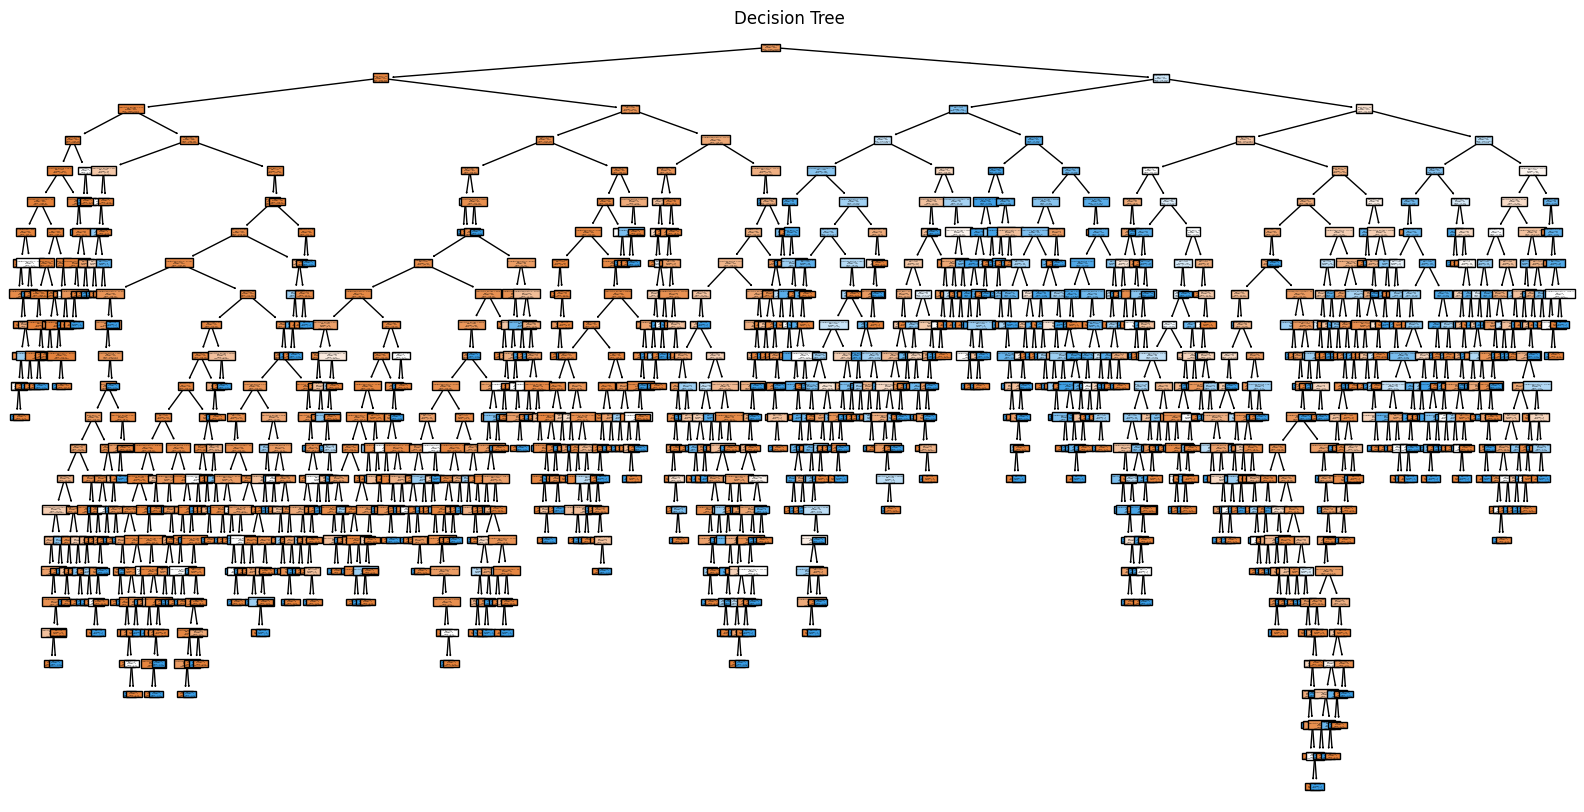

Decision Tree Accuracy: 0.8564476885644768

Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.91      0.91      2084
        True       0.53      0.56      0.55       382

    accuracy                           0.86      2466
   macro avg       0.73      0.74      0.73      2466
weighted avg       0.86      0.86      0.86      2466


Confusion Matrix:
[[1897  187]
 [ 167  215]]


In [ ]:
# Used code from D2L to create this
# Creating the decision tree model
clf = DecisionTreeClassifier(random_state=999)

# Training the decision tree model
clf.fit(X_train, y_train)

# Visualizing the decision tree
plt.figure(figsize=(20, 10))
tree.plot_tree(clf, feature_names=X.columns, class_names=['No Purchase', 'Purchase'], filled=True)
plt.title("Decision Tree")
plt.show()

# Making predictions on the test set
y_pred = clf.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

# Generating the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Generating the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


The Decision Tree appears to perform fairly well with a score of .86.

## Random Forest Model

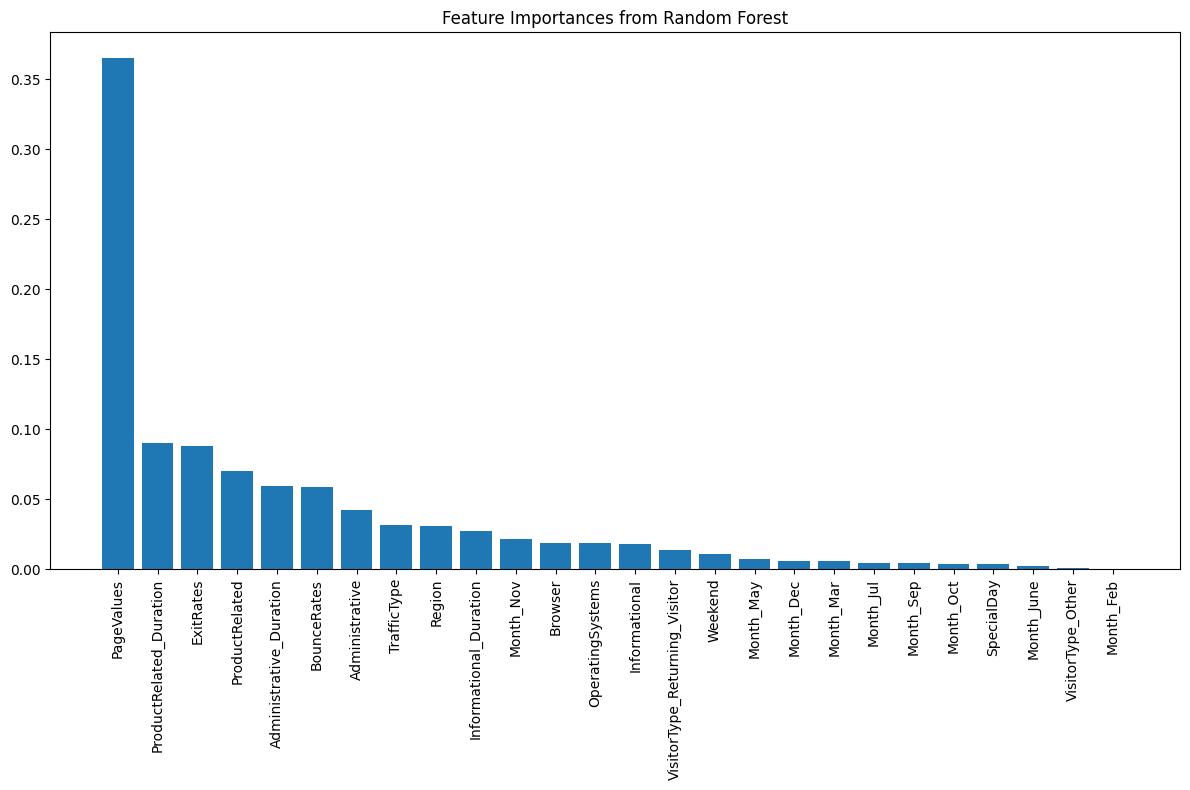

Random Forest Accuracy: 0.8965936739659367

Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.96      0.94      2084
        True       0.71      0.57      0.63       382

    accuracy                           0.90      2466
   macro avg       0.81      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466


Confusion Matrix:
[[1993   91]
 [ 164  218]]


In [ ]:
#Used code from D2L to create this

from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the classifier
rf_classifier.fit(X_train, y_train)

# Making predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Wanted to see what the Random Forest found was important
importances = rf_classifier.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(12, 8))
plt.title("Feature Importances from Random Forest")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# Calculating accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

# Generating the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


The Random Forest performs slightly better than the Decision Tree with a score of .89. PageValues is the most important feature.

## Artificial Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

ann_model = Sequential()
ann_model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.002), metrics=['accuracy'])

# Train the model
ann_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1, validation_data=(X_test, y_test))

# Predicting on the test set
y_pred_ann_probs = ann_model.predict(X_test)
y_pred_ann = (y_pred_ann_probs > 0.5).astype(int)

# Calculating accuracy
ann_accuracy = accuracy_score(y_test, y_pred_ann)
print("ANN Accuracy:", ann_accuracy)

# Generating the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))

# Generating the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


309/309 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7564 - loss: 5.7643 - val_accuracy: 0.8670 - val_loss: 2.6172
Epoch 2/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8208 - loss: 2.0711 - val_accuracy: 0.8715 - val_loss: 2.4508
Epoch 3/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8500 - loss: 2.1248 - val_accuracy: 0.8832 - val_loss: 0.6959
Epoch 4/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8338 - loss: 3.1169 - val_accuracy: 0.8719 - val_loss: 1.8972
Epoch 5/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8488 - loss: 2.5758 - val_accuracy: 0.7247 - val_loss: 1.8730
Epoch 6/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8431 - loss: 1.5288 - val_accuracy: 0.8260 - val_loss: 0.9492
Epoch 7/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8612 - loss: 0.8809 - val_accuracy: 0.8816 - val_loss: 0.6343
Epoch 8/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8524 - loss: 1.8322 - val_accuracy: 0.8877 - val_

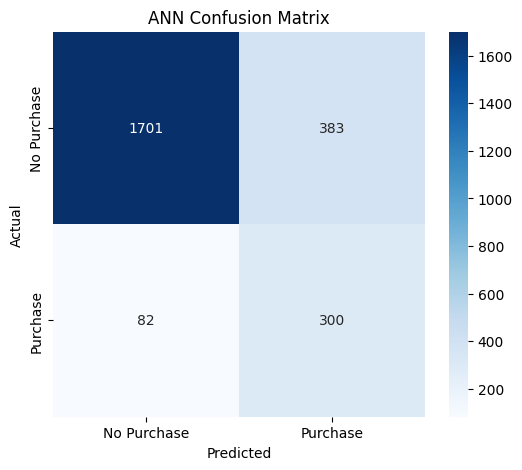

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 6. Compare Models

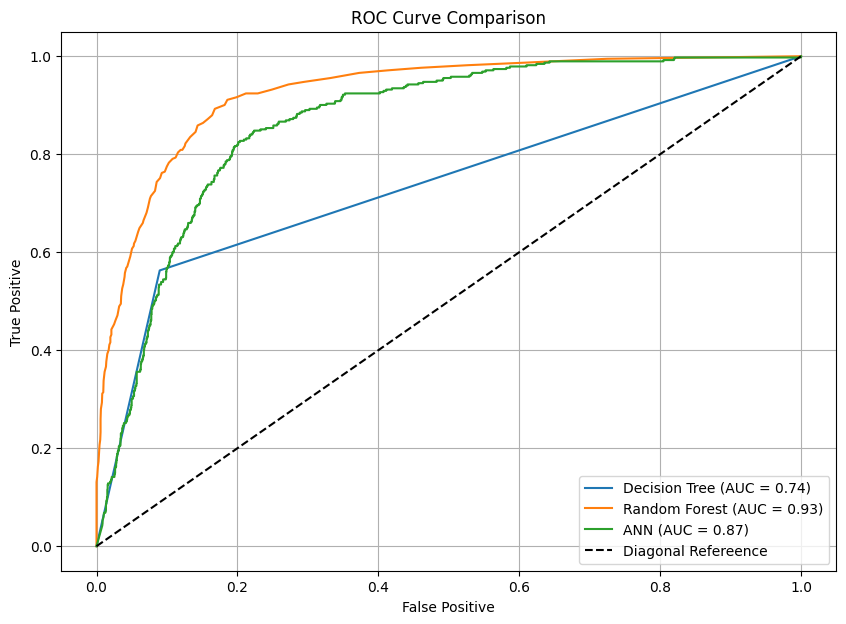

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for each model
y_pred_dt_probs = clf.predict_proba(X_test)[:, 1]  # Decision Tree
y_pred_rf_probs = rf_classifier.predict_proba(X_test)[:, 1]  # Random Forest
y_pred_ann_probs = y_pred_ann_probs.flatten()  # Already predicted above

# Compute ROC curve and AUC for each model
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_probs)
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_pred_ann_probs)

auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)
auc_ann = auc(fpr_ann, tpr_ann)

# Plot ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_ann, tpr_ann, label=f'ANN (AUC = {auc_ann:.2f})')


plt.plot([0, 1], [0, 1], 'k--', label='Diagonal Refereence')

plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# summary table
results_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'ANN'],
    'Accuracy': [accuracy_score(y_test, y_pred),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_ann)],
    'AUC': [auc_dt, auc_rf, auc_ann]
})

print(results_df.round(3))


           Model  Accuracy    AUC
0  Decision Tree     0.856  0.737
1  Random Forest     0.897  0.925
2            ANN     0.811  0.865


In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validation for decision tree
cv_scores_dt = cross_val_score(clf, X, y, cv=5)
print("Decision Tree CV Accuracy:", cv_scores_dt.mean())

# For Random Forest
cv_scores_rf = cross_val_score(rf_classifier, X, y, cv=5)
print("Random Forest CV Accuracy:", cv_scores_rf.mean())


Decision Tree CV Accuracy: 0.8461476074614762
Random Forest CV Accuracy: 0.8993511759935118


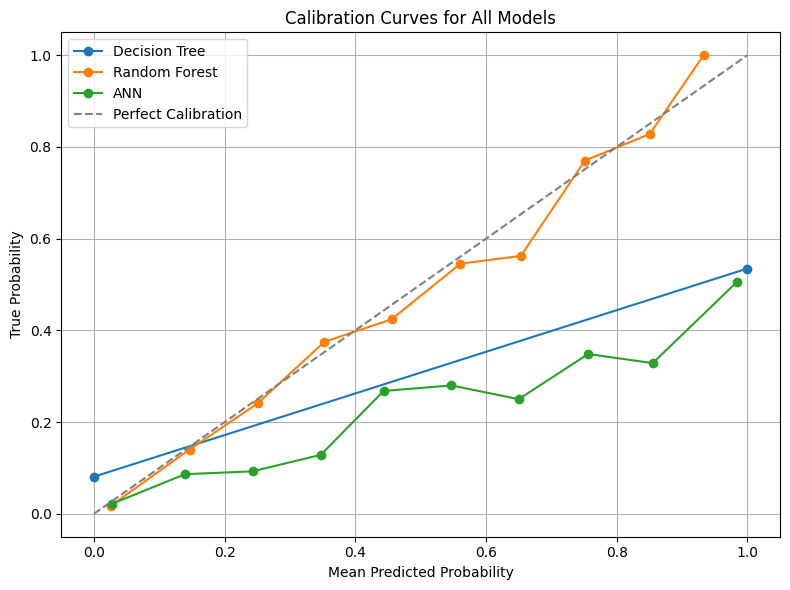

In [ ]:
# Used AI to get more ideas for comparing models
from sklearn.calibration import calibration_curve

# predicted probabilities for all models
dt_probs = clf.predict_proba(X_test)[:, 1]
rf_probs = rf_classifier.predict_proba(X_test)[:, 1]
ann_probs = y_pred_ann_probs.flatten()

# Compute calibration curves
prob_true_dt, prob_pred_dt = calibration_curve(y_test, dt_probs, n_bins=10)
prob_true_rf, prob_pred_rf = calibration_curve(y_test, rf_probs, n_bins=10)
prob_true_ann, prob_pred_ann = calibration_curve(y_test, ann_probs, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred_dt, prob_true_dt, marker='o', label='Decision Tree')
plt.plot(prob_pred_rf, prob_true_rf, marker='o', label='Random Forest')
plt.plot(prob_pred_ann, prob_true_ann, marker='o', label='ANN')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curves for All Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Overall I believe the Random Forest would be the best model for this dataset. THe AUC is high and its closest to diagonal on the Calibration Curve meaning that it is the highest calibrated.

# 7. Combinations of Variables


Different factors can influence the likelihood of purchase. For example, time spent, pages visited, and user type may not individually predict a purchase, but together they can. The combination of online shopper behaviors can strongly influence the outcome.

# 8. Pairplots or Interaction Plots

Yes, pairplots and interaction plots help show how variables interact. Pairplots reveal patterns or clusters. Interaction plots show how one variable affects another variable. You can use them to find relationships that aren't linear.

# Conclusion

- All three models performed fairly well
- The best performing model was the Decision Tree
- The most important feature was Page Values